In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
cult = pd.read_excel(r"C:\Users\hp\Downloads\MENTOR SHIP\Mentor_Cult_fit_Ritik.xlsx")

In [8]:
cult

,Unnamed: 0,ActivitySiteID,BookingEndDateTime,BookingStartTime,MaxBookees,Number_Booked,Price,BookingEndMonth,BookingEndDay,Booking_Start_Hour,Booking_Start_Min,Activity,Activity_Time,Activity_Duration
0,0,BRP,2018-04-01,9:00:00,35,29,1499,4,1,9,0,BodyCombat,09:00AM - 10:00AM,60
1,1,BRP,2018-04-01,10:00:00,20,15,1999,4,1,10,0,HattonABC,10:00AM - 11:00AM,60
2,2,HXP,2018-04-01,10:00:00,27,20,1999,4,1,10,0,StudioCyc,10:00AM - 11:00AM,60
3,3,HXP,2018-04-01,9:05:00,27,27,1999,4,1,9,5,StudioCyc,09:05AM - 10:05AM,60
4,4,TSC,2018-04-01,10:00:00,30,13,1299,4,1,10,0,BodyConditioning,10:00AM - 11:00AM,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266,3266,BRP,2018-06-30,9:00:00,35,21,1999,6,30,9,0,BodyAttack,09:00AM - 10:00AM,60
3267,3267,TSC,2018-06-30,8:30:00,24,11,2999,6,30,8,30,BarrePilates,08:30AM - 09:30AM,60
3268,3268,NBL,2018-06-30,12:00:00,60,9,2999,6,30,12,0,BarrePilates,12:00PM - 01:00PM,60
3269,3269,SBP,2018-06-30,8:30:00,20,6,3999,6,30,8,30,MMACond,08:30AM - 09:30AM,60


In [10]:
cult =cult.drop(columns=["Unnamed: 0"], errors="ignore")

In [12]:
cult["Booking_Rate"] = (
    cult["Number_Booked"] / cult["MaxBookees"]
) * 100

print(cult.shape)
cult.head()

(3271, 14)


,ActivitySiteID,BookingEndDateTime,BookingStartTime,MaxBookees,Number_Booked,Price,BookingEndMonth,BookingEndDay,Booking_Start_Hour,Booking_Start_Min,Activity,Activity_Time,Activity_Duration,Booking_Rate
0,BRP,2018-04-01,9:00:00,35,29,1499,4,1,9,0,BodyCombat,09:00AM - 10:00AM,60,82.857143
1,BRP,2018-04-01,10:00:00,20,15,1999,4,1,10,0,HattonABC,10:00AM - 11:00AM,60,75.000000
2,HXP,2018-04-01,10:00:00,27,20,1999,4,1,10,0,StudioCyc,10:00AM - 11:00AM,60,74.074074
3,HXP,2018-04-01,9:05:00,27,27,1999,4,1,9,5,StudioCyc,09:05AM - 10:05AM,60,100.000000
4,TSC,2018-04-01,10:00:00,30,13,1299,4,1,10,0,BodyConditioning,10:00AM - 11:00AM,60,43.333333


In [13]:
cult[[
    "MaxBookees",
    "Number_Booked",
    "Price",
    "Booking_Rate"
]].describe().round(2)

,MaxBookees,Number_Booked,Price,Booking_Rate
count,3271.00,3271.00,3271.00,3271.00
mean,32.22,17.13,1852.71,57.23
std,15.12,9.52,792.64,31.91
min,2.00,1.00,499.00,1.67
25%,24.00,10.00,1299.00,34.29
50%,30.00,16.00,1499.00,55.56
75%,35.00,24.00,2499.00,80.00
max,70.00,64.00,3999.00,516.67


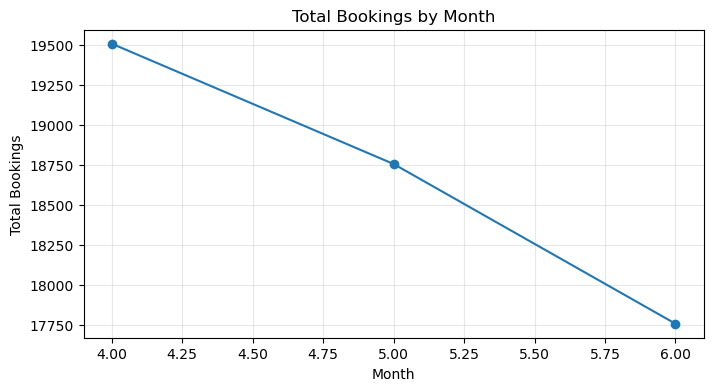

In [14]:
monthly = cult.groupby("BookingEndMonth")["Number_Booked"].sum()

plt.figure(figsize=(8,4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Total Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Total Bookings")
plt.grid(alpha=0.3)
plt.show()

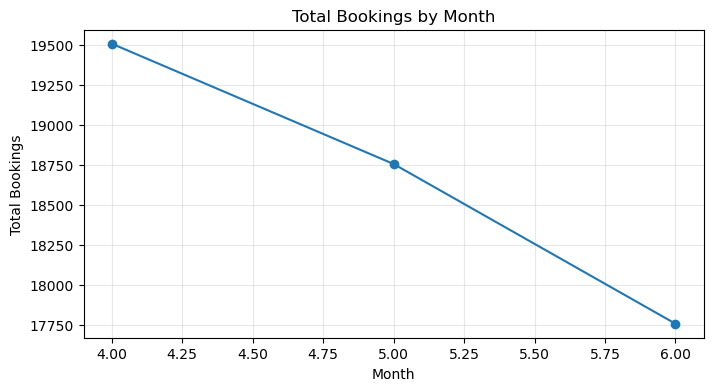

In [15]:
monthly = cult.groupby("BookingEndMonth")["Number_Booked"].sum()

plt.figure(figsize=(8,4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Total Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Total Bookings")
plt.grid(alpha=0.3)
plt.show()

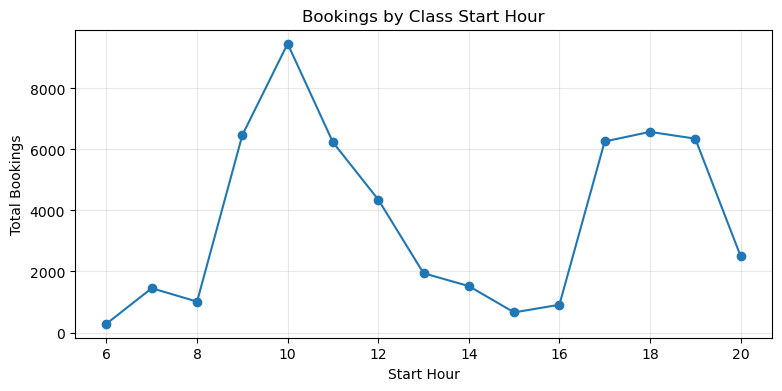

In [16]:
hourly = cult.groupby("Booking_Start_Hour")["Number_Booked"].sum()

plt.figure(figsize=(9,4))
plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Bookings by Class Start Hour")
plt.xlabel("Start Hour")
plt.ylabel("Total Bookings")
plt.grid(alpha=0.3)
plt.show()

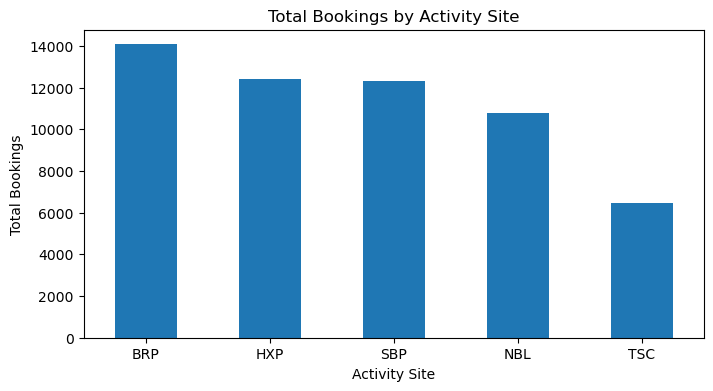

In [17]:
site_bookings = (
    cult.groupby("ActivitySiteID")["Number_Booked"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))
site_bookings.plot(kind="bar")
plt.title("Total Bookings by Activity Site")
plt.xlabel("Activity Site")
plt.ylabel("Total Bookings")
plt.xticks(rotation=0)
plt.show()


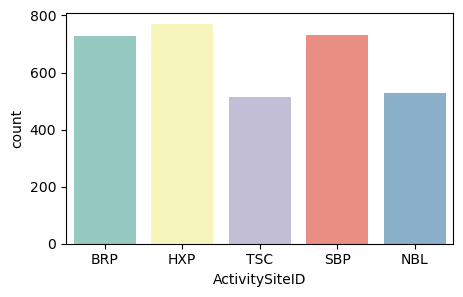

In [23]:
plt.figure(figsize=(5, 3))
sns.countplot(
    data=cult,
    x="ActivitySiteID",
    hue="ActivitySiteID",
    palette="Set3",
    legend=False,
)
plt.show()

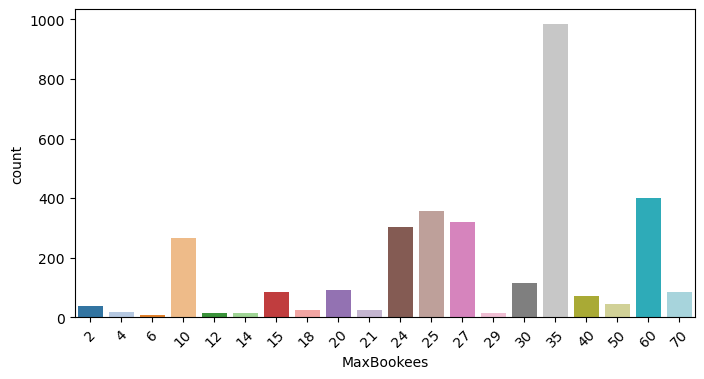

In [26]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=cult,
    x="MaxBookees",
    hue="MaxBookees",
    palette="tab20",
    legend=False,
)
plt.xticks(rotation=45)
plt.show()

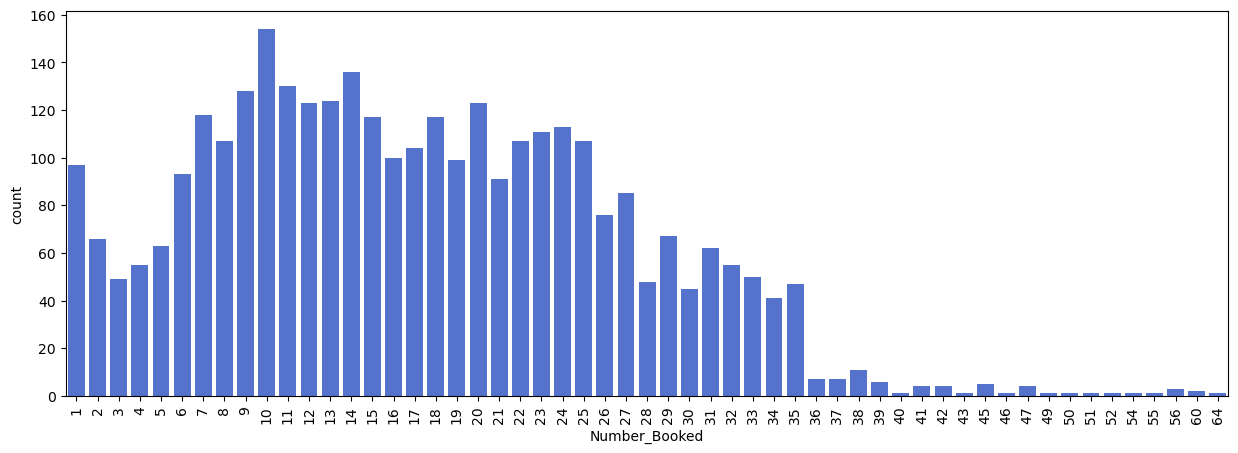

In [32]:
plt.figure(figsize=(15, 5))
sns.countplot(data=cult, x="Number_Booked", color="royalblue")
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Activity'>

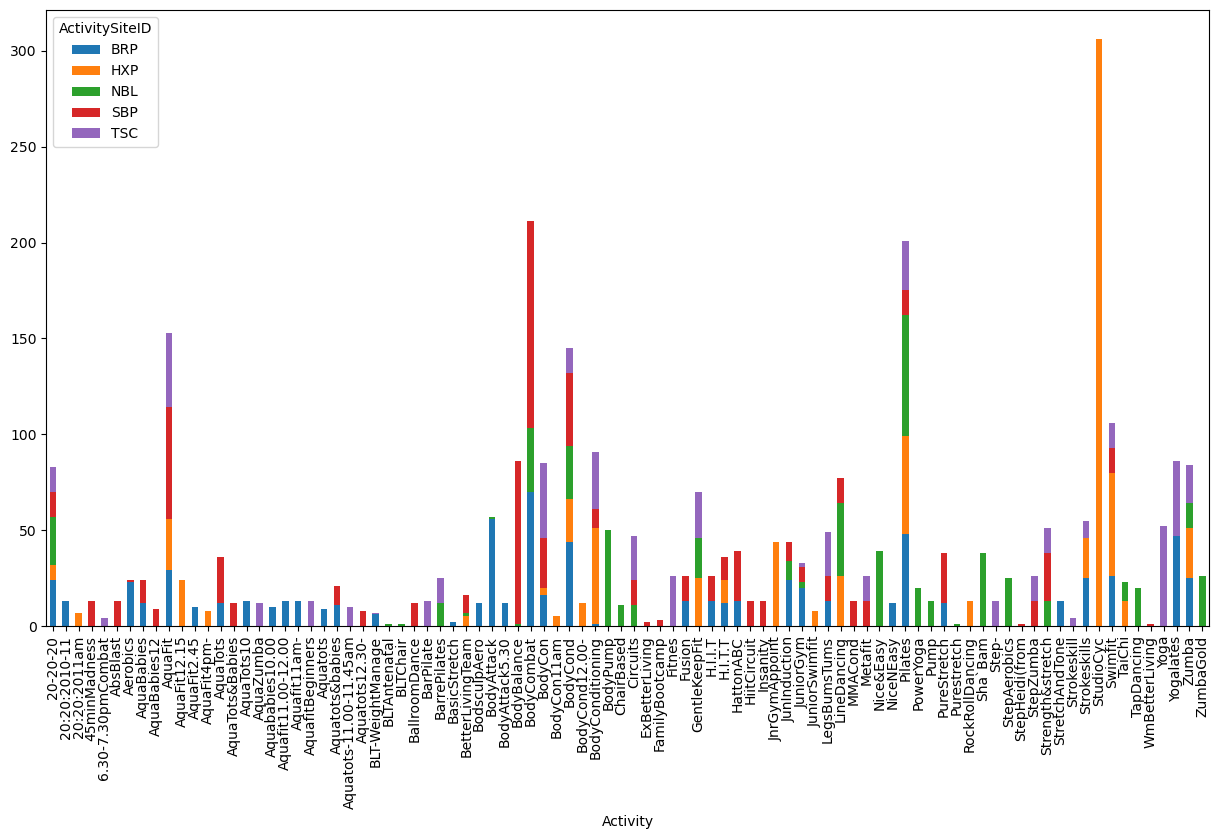

In [36]:
a = cult.pivot_table(index='Activity', columns='ActivitySiteID', aggfunc='size', fill_value=0)
a

cult['Activity'] = np.where(cult['Activity'] == 'Aquababies' , 
                                   cult['Activity'].str.replace('Aquababies', 'AquaBabies', regex=False), 
                                   cult['Activity'])

cult['Activity'] = np.where(cult['Activity'] == 'BltWeigh' , 
                                   cult['Activity'].str.replace('BltWeigh', 'BLT-WeightManage', regex=False), 
                                   cult['Activity'])
a.plot(kind='bar', stacked=True, figsize=(15, 8))

In [20]:
columns = [
    "MaxBookees",
    "Number_Booked",
    "Price",
    "Booking_Rate"
]

for col in columns:
    Q1 = cult[col].quantile(0.25)
    Q3 = cult[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cult[
        (cult[col] < lower) |
        (cult[col] > upper)
    ]

    print(col, ":", len(outliers), "outliers")

MaxBookees : 550 outliers
Number_Booked : 17 outliers
Price : 0 outliers
Booking_Rate : 7 outliers


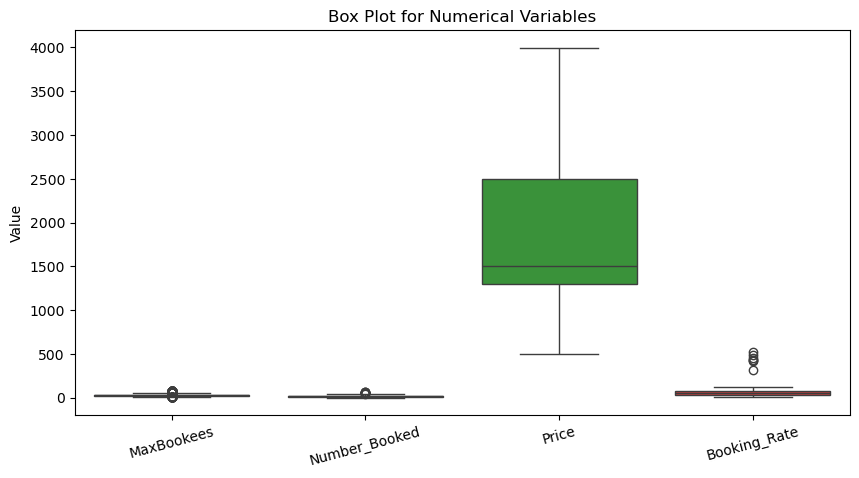

In [21]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=cult[
        ["MaxBookees",
         "Number_Booked",
         "Price",
         "Booking_Rate"]
    ]
)

plt.title("Box Plot for Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=15)
plt.show()

In [38]:
cult.nunique()

ActivitySiteID          5
BookingEndDateTime     91
BookingStartTime       61
MaxBookees             20
Number_Booked          55
Price                   9
BookingEndMonth         3
BookingEndDay          31
Booking_Start_Hour     15
Booking_Start_Min      11
Activity               90
Activity_Time          61
Activity_Duration       1
Booking_Rate          199
dtype: int64

In [40]:
file_name = 'Ritik_Cult_fit_EDA.xlsx'
 

cult.to_excel(file_name)

In [41]:
import os
print(os.path.abspath('Ritik_Cult_fit_EDA.xlsx'))

C:\Users\hp\mentormind cultfit\Ritik_Cult_fit_EDA.xlsx
